# Data Insights Dashboard – Online Food Delivery (Bangalore)

## Problem Statement
Organisations accumulate vast data but struggle to extract actionable insights. This dashboard
performs end-to-end EDA on an online food-delivery survey dataset collected from Bangalore
residents, delivering business intelligence across delivery time, customer satisfaction, and
customer preferences.

## Dataset
`onlinedeliverydata.csv` – 388 respondents, 55 variables across four themes:
1. Demographics
2. General purchase decision
3. Time of delivery factors
4. Restaurant ratings & satisfaction

## Objectives
1. Understand the Data
2. Exploratory Data Analysis
3. Data Insights
   - A. Delivery Time Analysis
   - B. Customer Satisfaction & Reviews
   - C. Customer Preferences

---
## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('data/onlinedeliverydata.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (388, 55)


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Medium (P1),Medium (P2),Meal(P1),Meal(P2),Perference(P1),Perference(P2),Ease and convenient,Time saving,More restaurant choices,Easy Payment option,More Offers and Discount,Good Food quality,Good Tracking system,Self Cooking,Health Concern,Late Delivery,Poor Hygiene,Bad past experience,Unavailability,Unaffordable,Long delivery time,Delay of delivery person getting assigned,Delay of delivery person picking up food,Wrong order delivered,Missing item,Order placed by mistake,Influence of time,Order Time,Maximum wait time,Residence in busy location,Google Maps Accuracy,Good Road Condition,Low quantity low time,Delivery person ability,Influence of rating,Less Delivery time,High Quality of package,Number of calls,Politeness,Freshness,Temperature,Good Taste,Good Quantity,Output,Reviews
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Food delivery apps,Web browser,Breakfast,Lunch,Non Veg foods (Lunch / Dinner),Bakery items (snacks),Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Neutral,Agree,Agree,Agree,Agree,Agree,Agree,Yes,Weekend (Sat & Sun),30 minutes,Agree,Neutral,Neutral,Neutral,Neutral,Yes,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Yes,Nil\n
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Food delivery apps,Web browser,Snacks,Dinner,Non Veg foods (Lunch / Dinner),Veg foods (Breakfast / Lunch / Dinner),Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Neutral,Agree,Strongly agree,Strongly agree,Agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Yes,Anytime (Mon-Sun),30 minutes,Strongly Agree,Neutral,Disagree,Strongly disagree,Agree,Yes,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Yes,Nil
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Food delivery apps,Direct call,Lunch,Snacks,Non Veg foods (Lunch / Dinner),Ice cream / Cool drinks,Strongly agree,Strongly agree,Strongly agree,Neutral,Neutral,Disagree,Neutral,Disagree,Neutral,Neutral,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Strongly agree,Agree,Neutral,Yes,Anytime (Mon-Sun),45 minutes,Agree,Strongly Agree,Neutral,Neutral,Agree,Yes,Important,Very Important,Moderately Important,Very Important,Very Important,Important,Very Important,Moderately Important,Yes,"Many a times payment gateways are an issue, so getting t..."
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Food delivery apps,Walk-in,Snacks,Dinner,Veg foods (Breakfast / Lunch / Dinner),Bakery items (snacks),Agree,Agree,Strongly agree,Agree,Strongly agree,Agree,Agree,Agree,Strongly agree,Neutral,Agree,Disagree,Disagree,Neutral,Agree,Agree,Agree,Disagree,Disagree,Neutral,Yes,Anytime (Mon-Sun),30 minutes,Disagree,Agree,Agree,Neutral,Agree,Yes,Very Important,Important,Moderately Important,Very Important,Very Important,Very Important,Very Important,Important,Yes,nil
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Walk-in,Direct call,Lunch,Dinner,Non Veg foods (Lunch / Dinner),Veg foods (Breakfast / Lunch / Dinner),Agree,Agree,Agree,Agree,Agree,Neutral,Neutral,Agree,Strongly agree,Strongly agree,Agree,Strongly agree,Agree,Disagree,Strongly agree,Strongly agree,Neutral,Neutral,Neutral,Disagree,Yes,Weekend (Sat & Sun),30 minutes,Agree,Agree,Agree,Agree,Agree,Yes,Important,Important,Moderately Important,Important,Important,Important,Very Important,Very Important,Yes,NIL


---
## 2. Understand the Data

In [3]:
print('=== Column names and data types ===')
df.info()

=== Column names and data types ===
<class 'pandas.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 55 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Age                                        388 non-null    int64  
 1   Gender                                     388 non-null    str    
 2   Marital Status                             388 non-null    str    
 3   Occupation                                 388 non-null    str    
 4   Monthly Income                             388 non-null    str    
 5   Educational Qualifications                 388 non-null    str    
 6   Family size                                388 non-null    int64  
 7   latitude                                   388 non-null    float64
 8   longitude                                  388 non-null    float64
 9   Pin code                                   388 non-null    int64  
 10  M

In [4]:
print('=== Statistical summary – numeric columns ===')
df.describe()

=== Statistical summary – numeric columns ===


,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [5]:
print('=== Missing values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing cells: {missing.sum()}')

=== Missing values ===
Reviews    1
dtype: int64

Total missing cells: 1


In [6]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 102


### Column Groups

| Group | Columns |
|-------|---------|
| Demographics | Age, Gender, Marital Status, Occupation, Monthly Income, Educational Qualifications, Family size, latitude, longitude, Pin code |
| Order Behaviour | Medium (P1/P2), Meal (P1/P2), Perference (P1/P2), Order Time, Maximum wait time, Influence of time |
| Barriers / Concerns | Self Cooking, Health Concern, Late Delivery, Poor Hygiene, Bad past experience, Unavailability, Unaffordable |
| Delivery Issues | Long delivery time, Delay getting assigned, Delay picking up food, Wrong order, Missing item, Order by mistake |
| Delivery Quality Ratings | Less Delivery time, High Quality of package, Number of calls, Politeness, Freshness, Temperature, Good Taste, Good Quantity |
| Location Factors | Residence in busy location, Google Maps Accuracy, Good Road Condition, Low quantity low time, Delivery person ability |
| Outcome | Output (Yes/No uses food delivery), Reviews |

---
## 3. Exploratory Data Analysis

### 3.1 Demographics

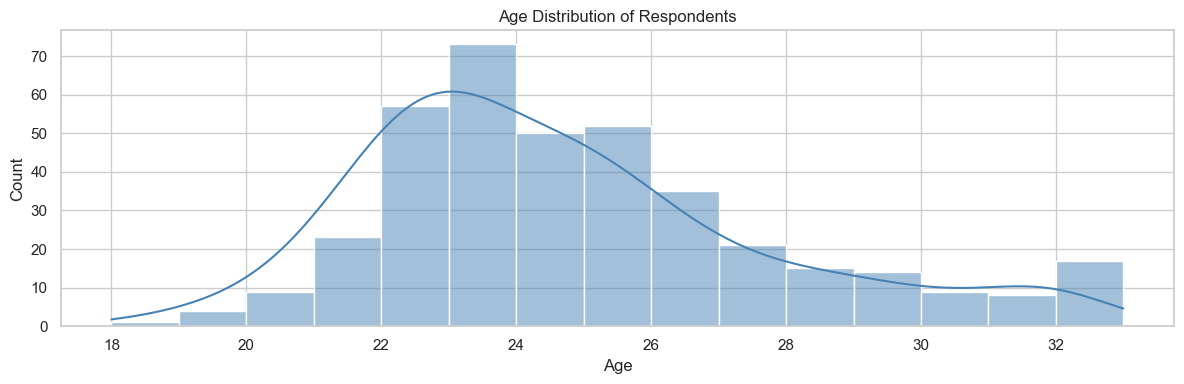

Age range: 18 – 33  |  Mean: 24.6


In [7]:
# Age distribution
plt.figure(figsize=(12, 4))
sns.histplot(df['Age'], bins=15, kde=True, color='steelblue')
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(f'Age range: {df["Age"].min()} – {df["Age"].max()}  |  Mean: {df["Age"].mean():.1f}')

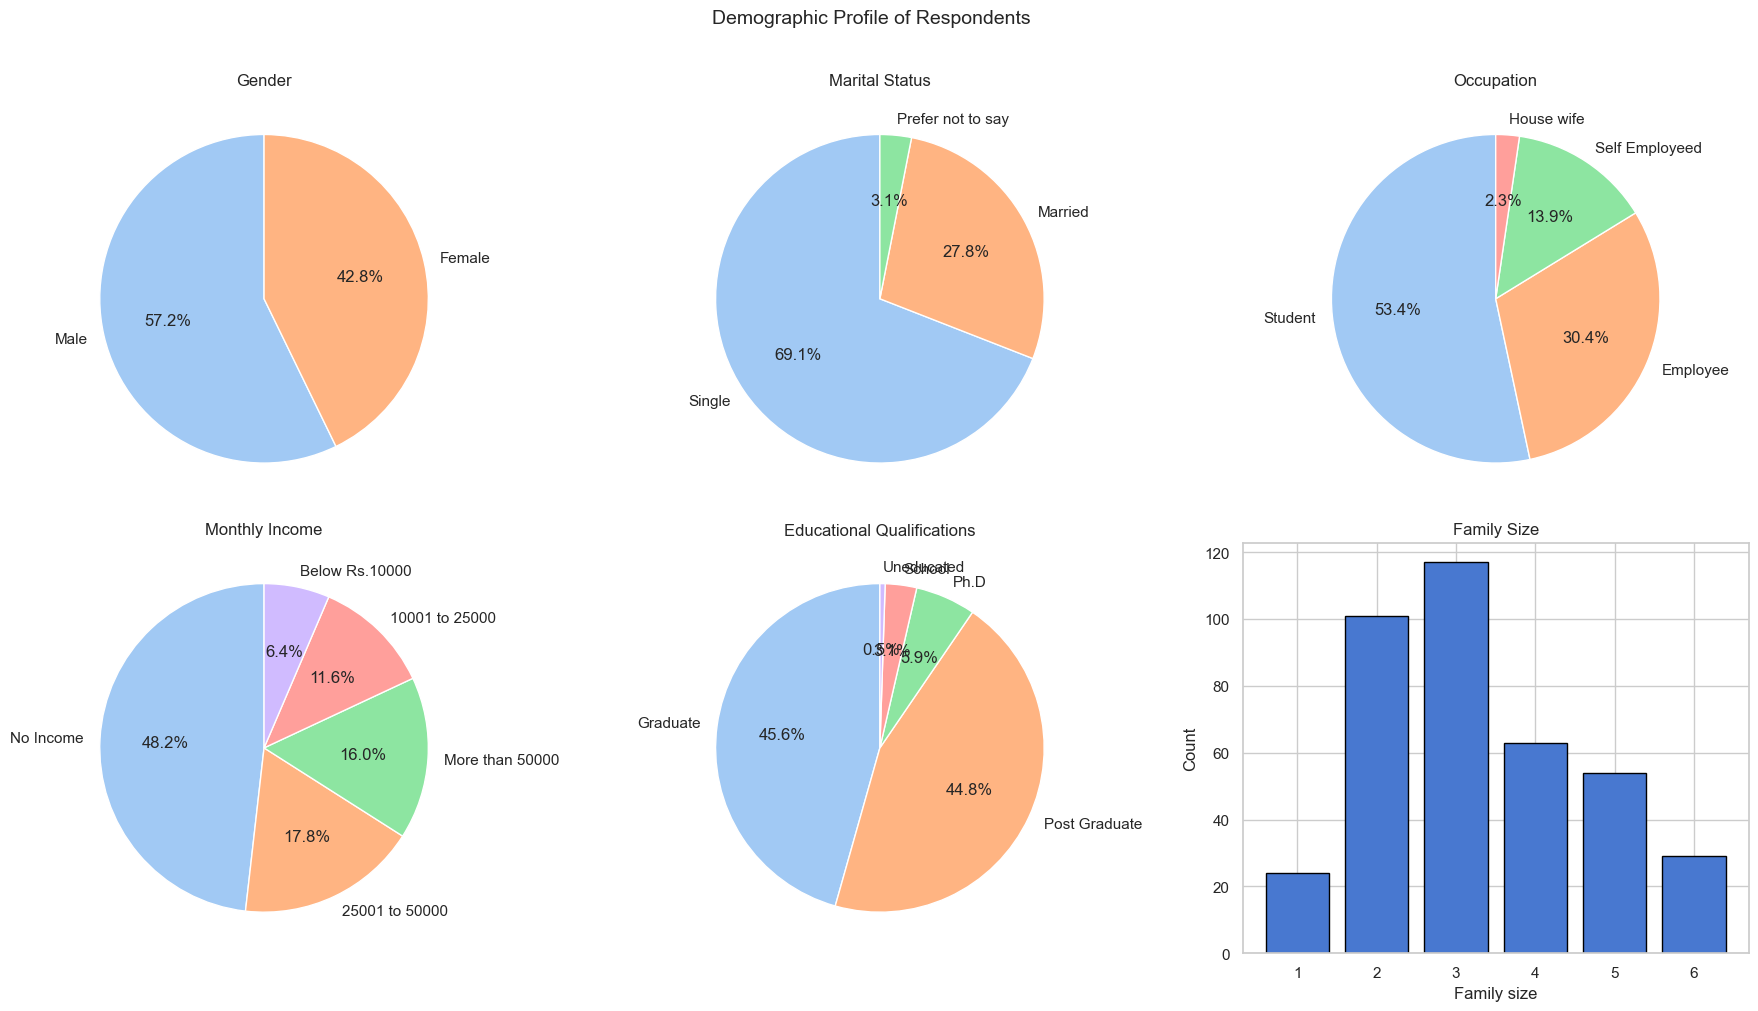

In [8]:
# Demographic breakdowns
demo_cols = ['Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, demo_cols):
    counts = df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           startangle=90, colors=sns.color_palette('pastel'))
    ax.set_title(col)

# Family size bar chart in the last subplot
family_counts = df['Family size'].value_counts().sort_index()
axes[5].bar(family_counts.index.astype(str), family_counts.values,
            color=sns.color_palette('muted')[0], edgecolor='black')
axes[5].set_title('Family Size')
axes[5].set_xlabel('Family size')
axes[5].set_ylabel('Count')

plt.suptitle('Demographic Profile of Respondents', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Order Behaviour

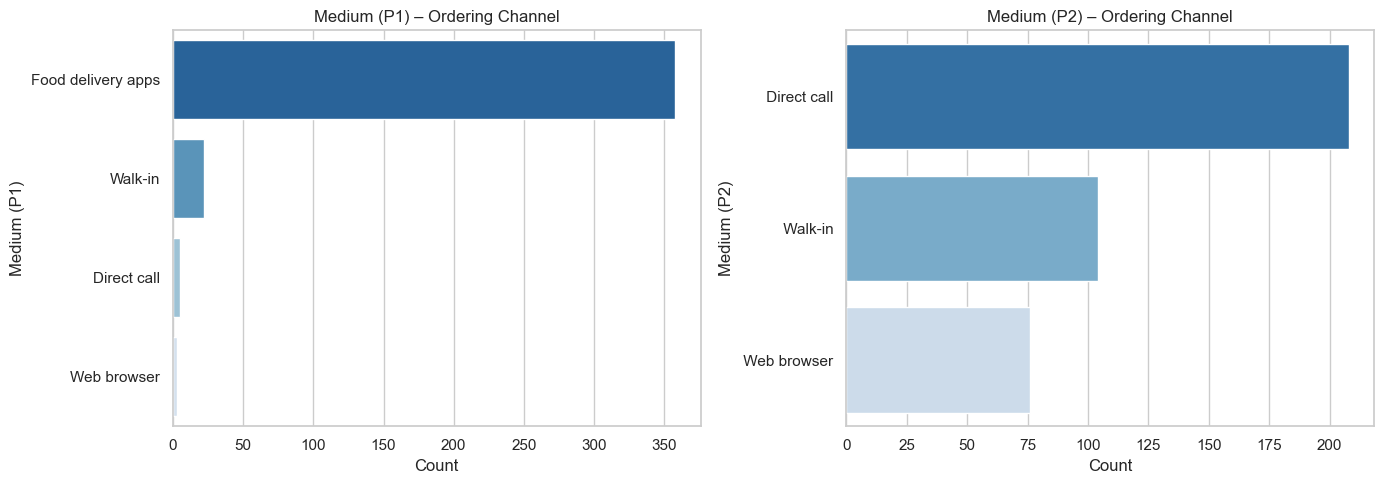

In [9]:
# Ordering medium preferences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['Medium (P1)', 'Medium (P2)']):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='Blues_r')
    ax.set_title(f'{col} – Ordering Channel')
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

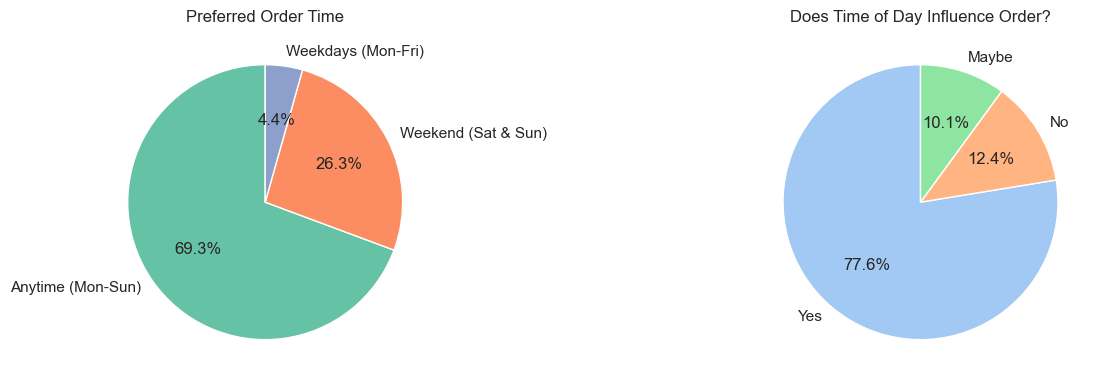

In [10]:
# Order timing preference
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

order_time = df['Order Time'].value_counts()
axes[0].pie(order_time.values, labels=order_time.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set2'))
axes[0].set_title('Preferred Order Time')

inf_time = df['Influence of time'].value_counts()
axes[1].pie(inf_time.values, labels=inf_time.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('pastel'))
axes[1].set_title('Does Time of Day Influence Order?')

plt.tight_layout()
plt.show()

### 3.3 Reasons FOR Using Food Delivery

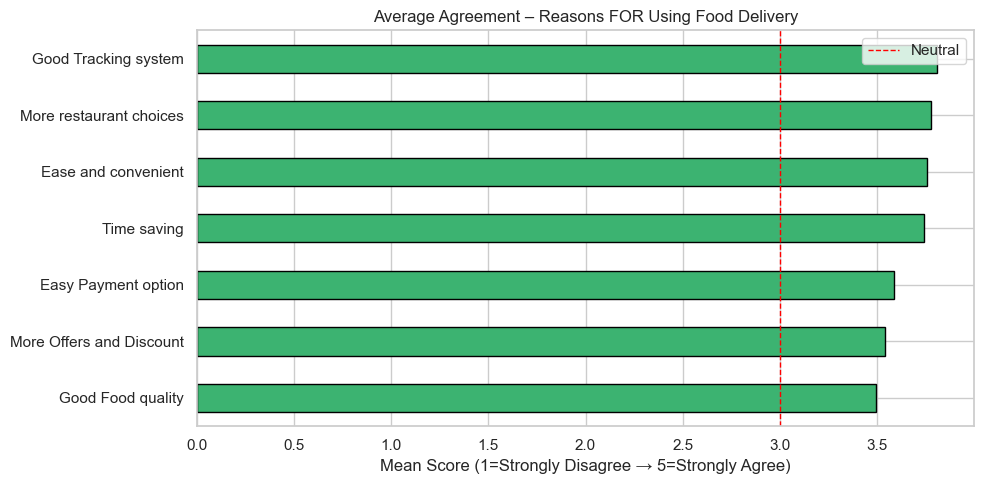

In [11]:
# Map Likert responses to numeric scores
likert_map = {
    'Strongly agree': 5, 'Strongly Agree': 5,
    'Agree'         : 4,
    'Neutral'       : 3,
    'Disagree'      : 2,
    'Strongly disagree': 1, 'Strongly Disagree': 1
}

for_cols = [
    'Ease and convenient', 'Time saving', 'More restaurant choices',
    'Easy Payment option', 'More Offers and Discount', 'Good Food quality',
    'Good Tracking system'
]
for_scores = df[for_cols].replace(likert_map).mean().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
for_scores.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Average Agreement – Reasons FOR Using Food Delivery')
plt.xlabel('Mean Score (1=Strongly Disagree → 5=Strongly Agree)')
plt.axvline(3, color='red', linestyle='--', linewidth=1, label='Neutral')
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Reasons AGAINST Using Food Delivery

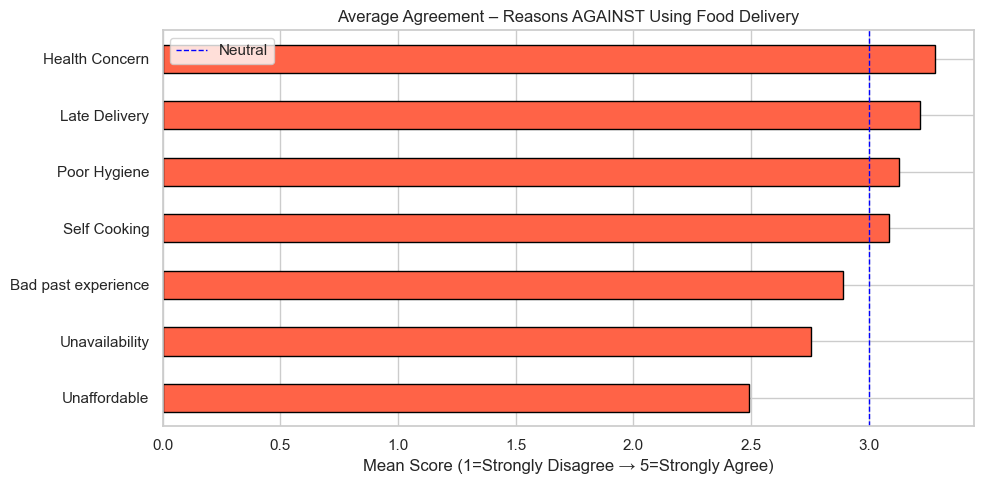

In [12]:
against_cols = [
    'Self Cooking', 'Health Concern', 'Late Delivery',
    'Poor Hygiene', 'Bad past experience', 'Unavailability', 'Unaffordable'
]
against_scores = df[against_cols].replace(likert_map).mean().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
against_scores.plot(kind='barh', color='tomato', edgecolor='black')
plt.title('Average Agreement – Reasons AGAINST Using Food Delivery')
plt.xlabel('Mean Score (1=Strongly Disagree → 5=Strongly Agree)')
plt.axvline(3, color='blue', linestyle='--', linewidth=1, label='Neutral')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 Output: Who Actually Uses Food Delivery?

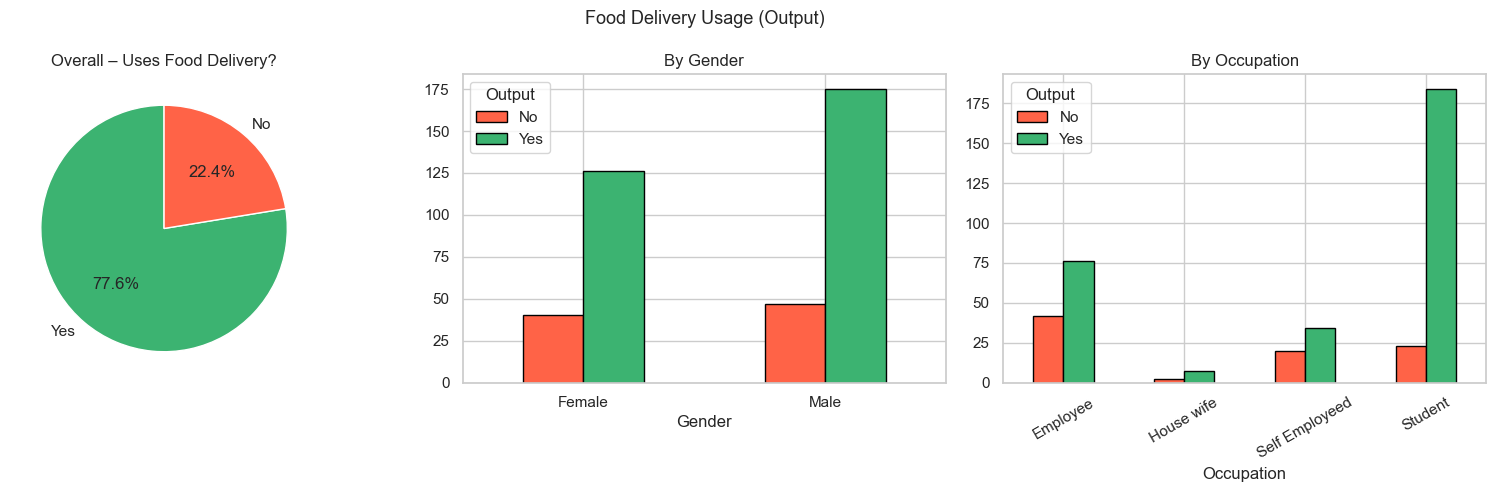

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall
output_counts = df['Output'].value_counts()
axes[0].pie(output_counts.values, labels=output_counts.index, autopct='%1.1f%%',
            colors=['mediumseagreen', 'tomato'], startangle=90)
axes[0].set_title('Overall – Uses Food Delivery?')

# By Gender
gender_output = df.groupby(['Gender', 'Output']).size().unstack(fill_value=0)
gender_output.plot(kind='bar', ax=axes[1], color=['tomato', 'mediumseagreen'], edgecolor='black')
axes[1].set_title('By Gender')
axes[1].set_xlabel('Gender')
axes[1].tick_params(axis='x', rotation=0)

# By Occupation
occ_output = df.groupby(['Occupation', 'Output']).size().unstack(fill_value=0)
occ_output.plot(kind='bar', ax=axes[2], color=['tomato', 'mediumseagreen'], edgecolor='black')
axes[2].set_title('By Occupation')
axes[2].set_xlabel('Occupation')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Food Delivery Usage (Output)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Data Insights

### 4A. Delivery Time Analysis

In [14]:
# Map wait-time categories to numeric minutes
wait_time_map = {
    '15 minutes'         : 15,
    '30 minutes'         : 30,
    '45 minutes'         : 45,
    '60 minutes'         : 60,
    'More than 60 minutes': 75
}
df['wait_time_mins'] = df['Maximum wait time'].map(wait_time_map)

min_wait = df['wait_time_mins'].min()
max_wait = df['wait_time_mins'].max()
modal_wait = df['Maximum wait time'].mode()[0]
mean_wait = df['wait_time_mins'].mean()

print(f'Minimum acceptable wait time : {min_wait} minutes')
print(f'Maximum acceptable wait time : {max_wait} minutes (coded as 75 = >60 min)')
print(f'Most common acceptable wait  : {modal_wait}')
print(f'Average acceptable wait time : {mean_wait:.1f} minutes')

Minimum acceptable wait time : 15 minutes
Maximum acceptable wait time : 75 minutes (coded as 75 = >60 min)
Most common acceptable wait  : 45 minutes
Average acceptable wait time : 39.5 minutes


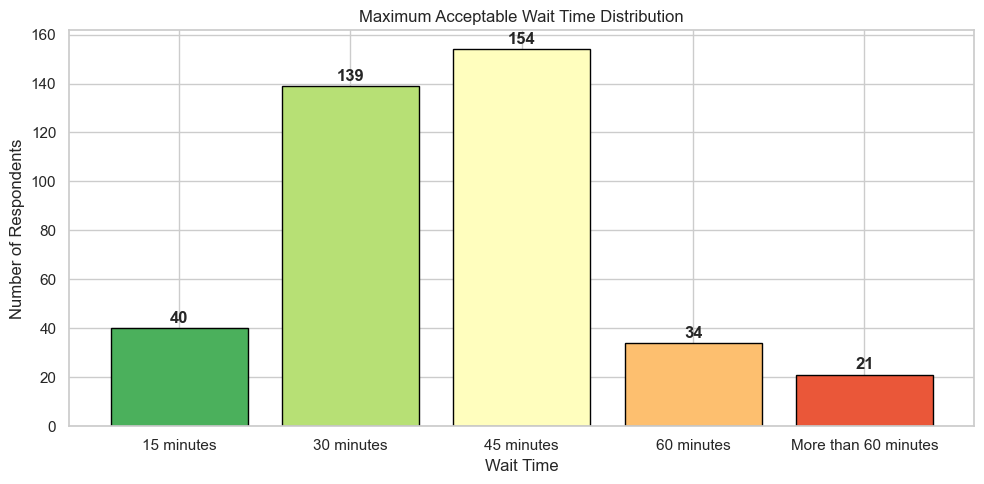

In [15]:
# Wait-time distribution chart
wait_order = ['15 minutes', '30 minutes', '45 minutes', '60 minutes', 'More than 60 minutes']
wait_counts = df['Maximum wait time'].value_counts().reindex(wait_order)

plt.figure(figsize=(10, 5))
bars = plt.bar(wait_counts.index, wait_counts.values,
               color=sns.color_palette('RdYlGn_r', len(wait_order)), edgecolor='black')
plt.title('Maximum Acceptable Wait Time Distribution')
plt.xlabel('Wait Time')
plt.ylabel('Number of Respondents')
for bar, val in zip(bars, wait_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Locality with most and least number of orders (by Pin code)
locality_orders = df['Pin code'].value_counts()

most_orders_pin  = locality_orders.idxmax()
most_orders_count = locality_orders.max()
least_orders_pin  = locality_orders.idxmin()
least_orders_count = locality_orders.min()

print(f'Locality with MOST orders  : Pin code {most_orders_pin}  ({most_orders_count} orders)')
print(f'Locality with LEAST orders : Pin code {least_orders_pin} ({least_orders_count} order)')
print()
print('Top 10 localities by order volume:')
print(locality_orders.head(10).to_string())

Locality with MOST orders  : Pin code 560009  (36 orders)
Locality with LEAST orders : Pin code 560033 (1 order)

Top 10 localities by order volume:
Pin code
560009    36
560038    16
560010    14
560076    12
560034    11
560095    11
560036     9
560075     9
560001     8
560066     8


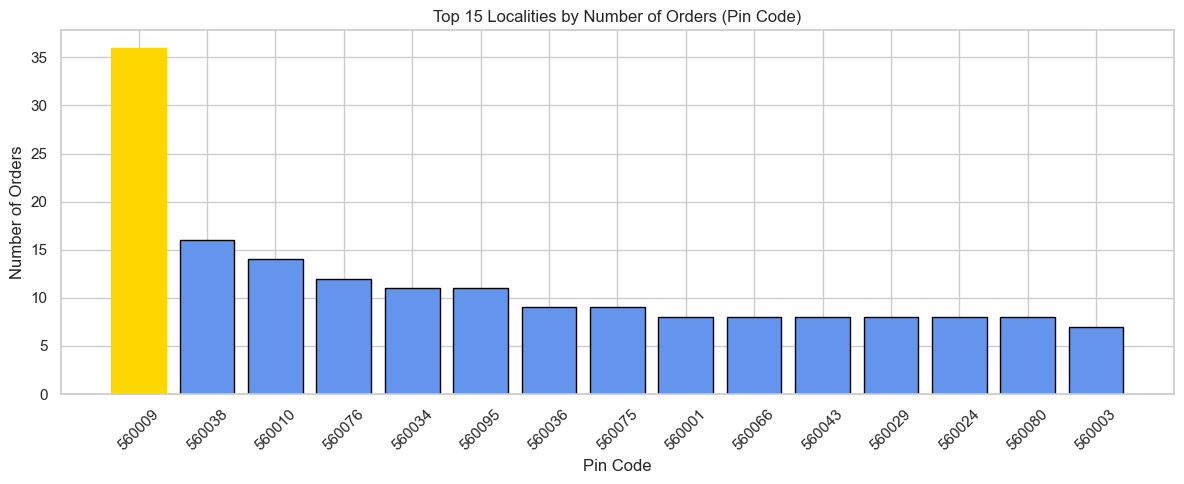

In [17]:
# Top 15 localities chart
top_localities = locality_orders.head(15)

plt.figure(figsize=(12, 5))
bars = plt.bar(top_localities.index.astype(str), top_localities.values,
               color='cornflowerblue', edgecolor='black')
bars[0].set_color('gold')   # highlight top locality
plt.title('Top 15 Localities by Number of Orders (Pin Code)')
plt.xlabel('Pin Code')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

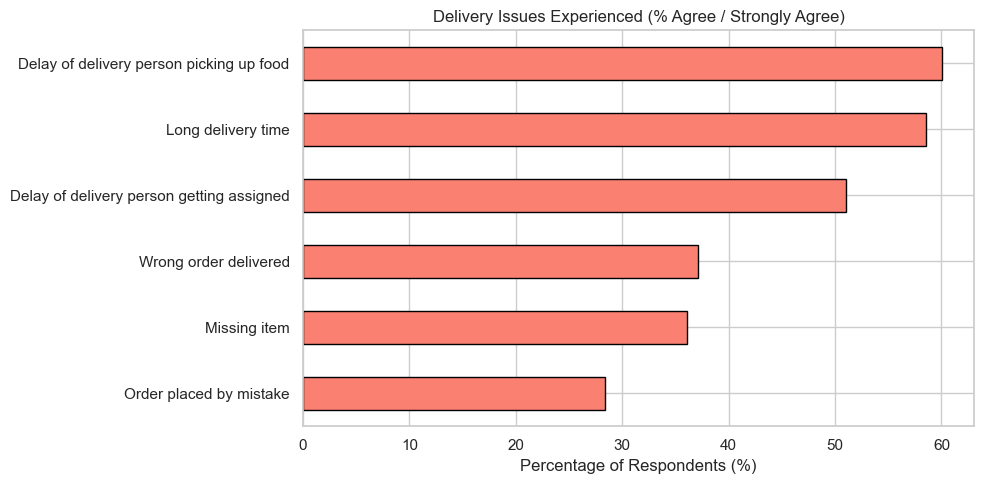

In [18]:
# Delivery issue frequency (% who Agree or Strongly Agree)
issue_cols = [
    'Long delivery time',
    'Delay of delivery person getting assigned',
    'Delay of delivery person picking up food',
    'Wrong order delivered',
    'Missing item',
    'Order placed by mistake'
]
agree_set = {'Agree', 'Strongly agree', 'Strongly Agree'}
issue_pct = {col: (df[col].isin(agree_set).sum() / len(df)) * 100 for col in issue_cols}
issue_series = pd.Series(issue_pct).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
issue_series.plot(kind='barh', color='salmon', edgecolor='black')
plt.title('Delivery Issues Experienced (% Agree / Strongly Agree)')
plt.xlabel('Percentage of Respondents (%)')
plt.tight_layout()
plt.show()

### 4B. Customer Satisfaction & Reviews

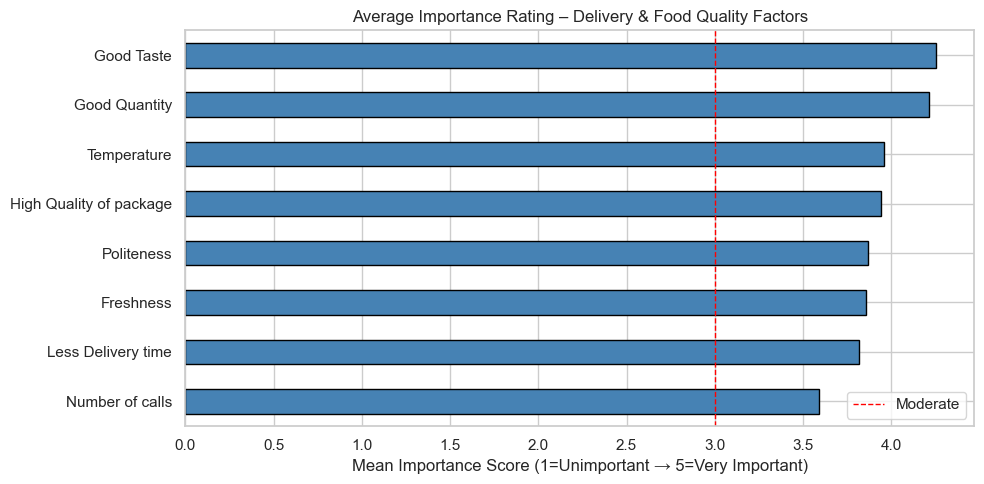

Importance scores (sorted):
Good Taste                 4.255155
Good Quantity               4.21134
Temperature                3.958763
High Quality of package    3.940722
Politeness                 3.865979
Freshness                   3.85567
Less Delivery time         3.814433
Number of calls            3.590206


In [19]:
# Map importance ratings to numeric
importance_map = {
    'Very Important'     : 5,
    'Important'          : 4,
    'Moderately Important': 3,
    'Slightly Important' : 2,
    'Unimportant'        : 1
}

rating_cols = [
    'Less Delivery time', 'High Quality of package', 'Number of calls',
    'Politeness', 'Freshness ', 'Temperature', 'Good Taste ', 'Good Quantity'
]
rating_scores = df[rating_cols].replace(importance_map).mean().sort_values(ascending=True)
rating_scores.index = [c.strip() for c in rating_scores.index]

plt.figure(figsize=(10, 5))
bars = rating_scores.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Average Importance Rating – Delivery & Food Quality Factors')
plt.xlabel('Mean Importance Score (1=Unimportant → 5=Very Important)')
plt.axvline(3, color='red', linestyle='--', linewidth=1, label='Moderate')
plt.legend()
plt.tight_layout()
plt.show()

print('Importance scores (sorted):')
print(rating_scores.sort_values(ascending=False).to_string())

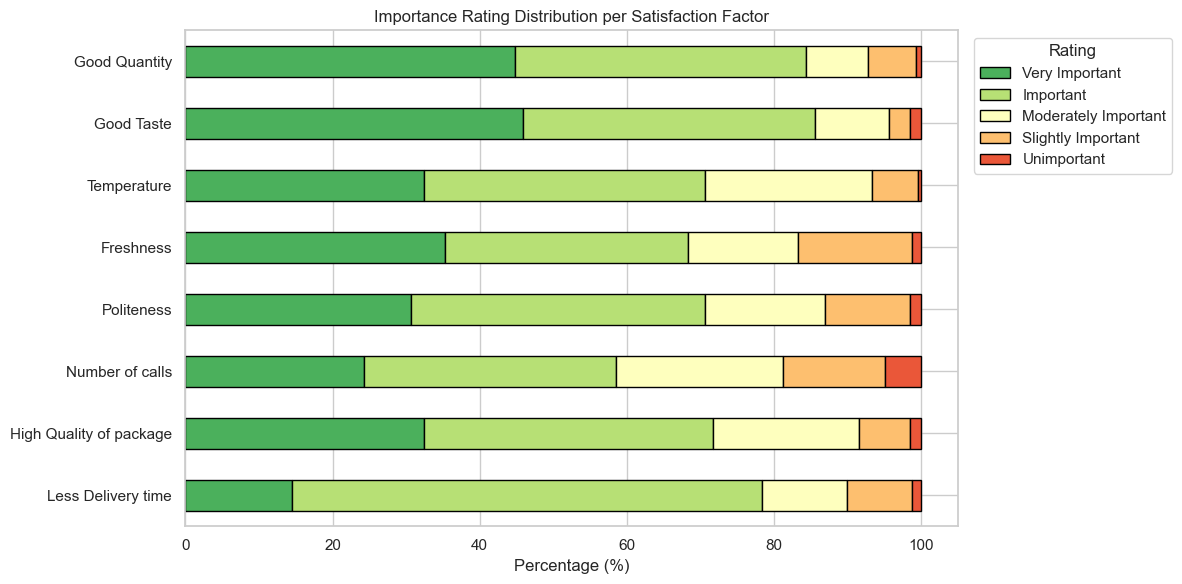

In [20]:
# Distribution of each rating factor (stacked bar)
importance_order = ['Very Important', 'Important', 'Moderately Important',
                    'Slightly Important', 'Unimportant']

rating_dist = pd.DataFrame()
for col in rating_cols:
    counts = df[col].value_counts().reindex(importance_order, fill_value=0)
    pct = counts / counts.sum() * 100
    rating_dist[col.strip()] = pct

rating_dist = rating_dist.T

rating_dist.plot(kind='barh', stacked=True, figsize=(12, 6),
                 color=sns.color_palette('RdYlGn', 5)[::-1], edgecolor='black')
plt.title('Importance Rating Distribution per Satisfaction Factor')
plt.xlabel('Percentage (%)')
plt.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

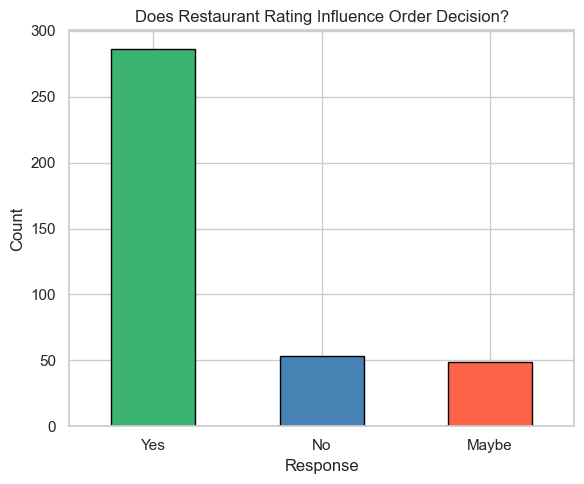

In [21]:
# Influence of restaurant rating on ordering decision
influence_rating = df['Influence of rating'].value_counts()

plt.figure(figsize=(6, 5))
influence_rating.plot(kind='bar',
                      color=['mediumseagreen', 'steelblue', 'tomato'], edgecolor='black')
plt.title('Does Restaurant Rating Influence Order Decision?')
plt.xlabel('Response')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

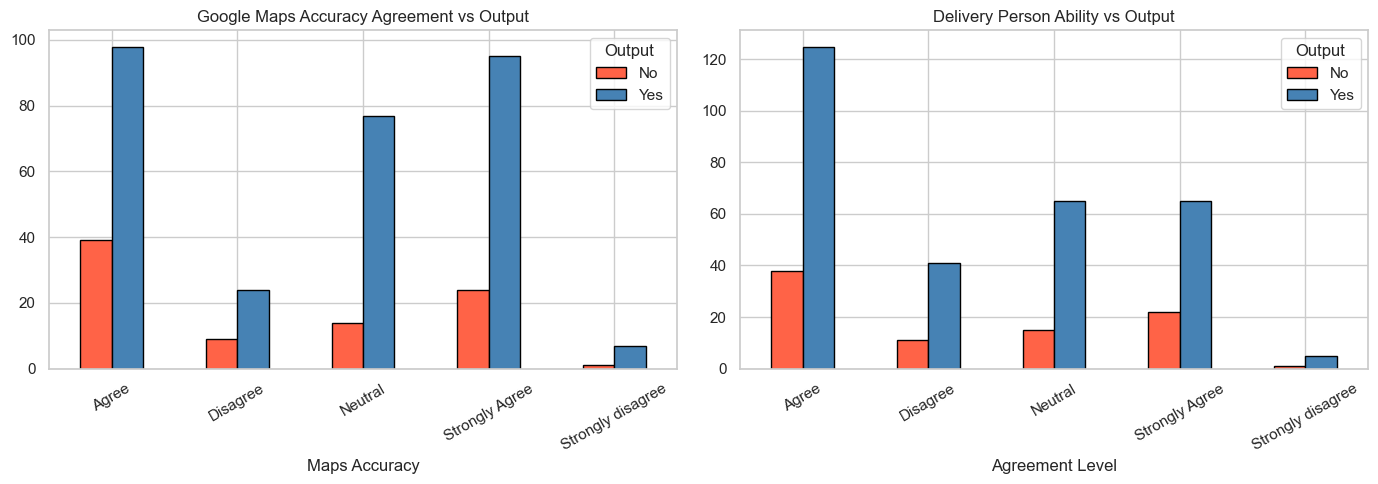

In [22]:
# Delivery quality factors vs Output (Yes/No uses delivery)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Google Maps Accuracy vs Output
maps_output = df.groupby(['Google Maps Accuracy', 'Output']).size().unstack(fill_value=0)
maps_output.plot(kind='bar', ax=axes[0], color=['tomato', 'steelblue'], edgecolor='black')
axes[0].set_title('Google Maps Accuracy Agreement vs Output')
axes[0].set_xlabel('Maps Accuracy')
axes[0].tick_params(axis='x', rotation=30)

# Delivery person ability vs Output
person_output = df.groupby(['Delivery person ability', 'Output']).size().unstack(fill_value=0)
person_output.plot(kind='bar', ax=axes[1], color=['tomato', 'steelblue'], edgecolor='black')
axes[1].set_title('Delivery Person Ability vs Output')
axes[1].set_xlabel('Agreement Level')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [23]:
# Sample customer reviews
reviews = df['Reviews'].dropna()
reviews_text = reviews[reviews.str.strip().str.lower() != 'nil']

print(f'Total non-null, non-"Nil" reviews: {len(reviews_text)}')
print()
print('=== Sample Customer Reviews ===')
for i, review in enumerate(reviews_text.sample(min(10, len(reviews_text)),
                                                random_state=42).values, 1):
    print(f'{i:2}. {review[:200]}')
    print()

Total non-null, non-"Nil" reviews: 241

=== Sample Customer Reviews ===
 1. I expect quality food rather than delivery time and ratings

 2. I expect faster delivery in my area

 3. Love to order online 

 4. Very few times I have  had bad experienced by aggregator or restaurant 

 5. I had bad quality order delivered twice

 6. less responsive delivery men. Also prevalent late deliveries

 7. Delivery people are working hard. Can't complain

 8. I require the food to be undamaged. Mostly the food is tampered

 9. Prefer hygienic delivery people

10. The delivery to my locations are done pretty fast



### 4C. Customer Preferences

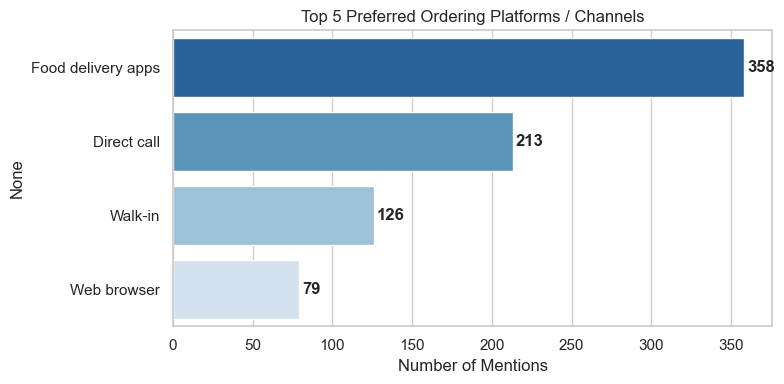

Top 5 Ordering Platforms:
Food delivery apps    358
Direct call           213
Walk-in               126
Web browser            79


In [24]:
# ── Top 5 Ordering Platforms (from Medium P1 & P2 combined) ──
# Note: The dataset does not contain individual restaurant names.
# 'Medium (P1)' and 'Medium (P2)' capture the platforms/channels customers
# prefer for placing orders – used here as the 'restaurant/platform' preference.
medium_combined = pd.concat([df['Medium (P1)'], df['Medium (P2)']]).str.strip()
top_platforms = medium_combined.value_counts().head(5)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_platforms.values, y=top_platforms.index, palette='Blues_r')
plt.title('Top 5 Preferred Ordering Platforms / Channels')
plt.xlabel('Number of Mentions')
for i, v in enumerate(top_platforms.values):
    plt.text(v + 2, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 Ordering Platforms:')
print(top_platforms.to_string())

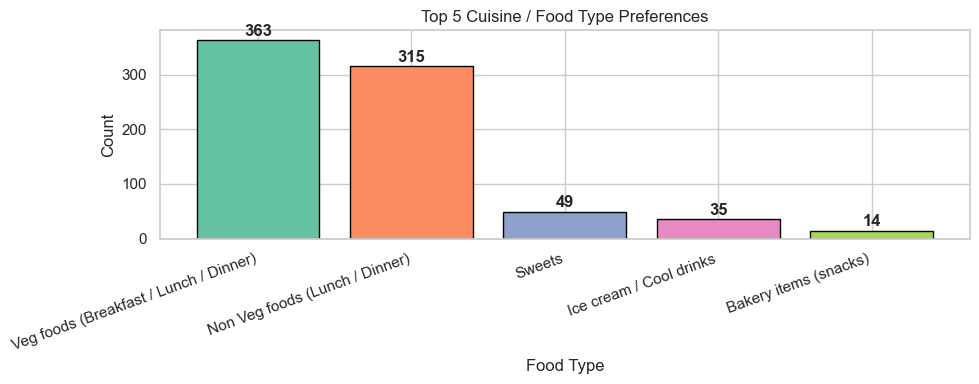

Top 5 Cuisines / Food Preferences:
Veg foods (Breakfast / Lunch / Dinner)    363
Non Veg foods (Lunch / Dinner)            315
Sweets                                     49
Ice cream / Cool drinks                    35
Bakery items (snacks)                      14


In [25]:
# ── Top 5 Cuisines / Food Preferences (from Perference P1 & P2 combined) ──
pref_combined = pd.concat([df['Perference(P1)'], df['Perference(P2)']]).str.strip()
top_cuisines = pref_combined.value_counts().head(5)

plt.figure(figsize=(10, 4))
bars = plt.bar(top_cuisines.index, top_cuisines.values,
               color=sns.color_palette('Set2', len(top_cuisines)), edgecolor='black')
plt.title('Top 5 Cuisine / Food Type Preferences')
plt.xlabel('Food Type')
plt.ylabel('Count')
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, top_cuisines.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 Cuisines / Food Preferences:')
print(top_cuisines.to_string())

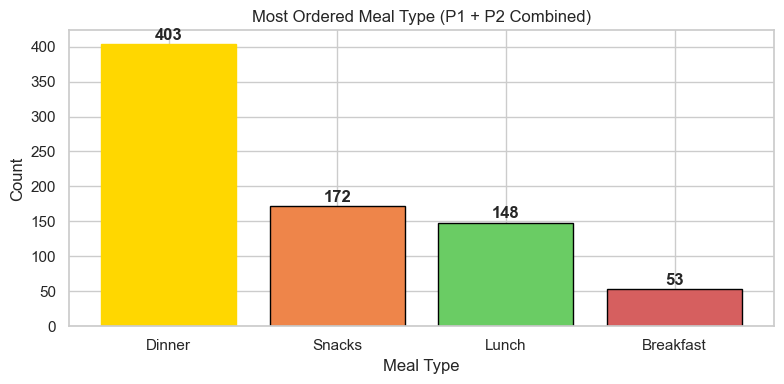

Most ordered meal type: Dinner (403 mentions)

All meal counts:
Dinner       403
Snacks       172
Lunch        148
Breakfast     53


In [26]:
# ── Most Ordered Meal (from Meal P1 & P2 combined) ──
meal_combined = pd.concat([df['Meal(P1)'], df['Meal(P2)']]).str.strip()
meal_counts = meal_combined.value_counts()
most_ordered = meal_counts.idxmax()

plt.figure(figsize=(8, 4))
bars = plt.bar(meal_counts.index, meal_counts.values,
               color=sns.color_palette('muted', len(meal_counts)), edgecolor='black')
bars[list(meal_counts.index).index(most_ordered)].set_color('gold')
plt.title('Most Ordered Meal Type (P1 + P2 Combined)')
plt.xlabel('Meal Type')
plt.ylabel('Count')
for bar, val in zip(bars, meal_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Most ordered meal type: {most_ordered} ({meal_counts.max()} mentions)')
print()
print('All meal counts:')
print(meal_counts.to_string())

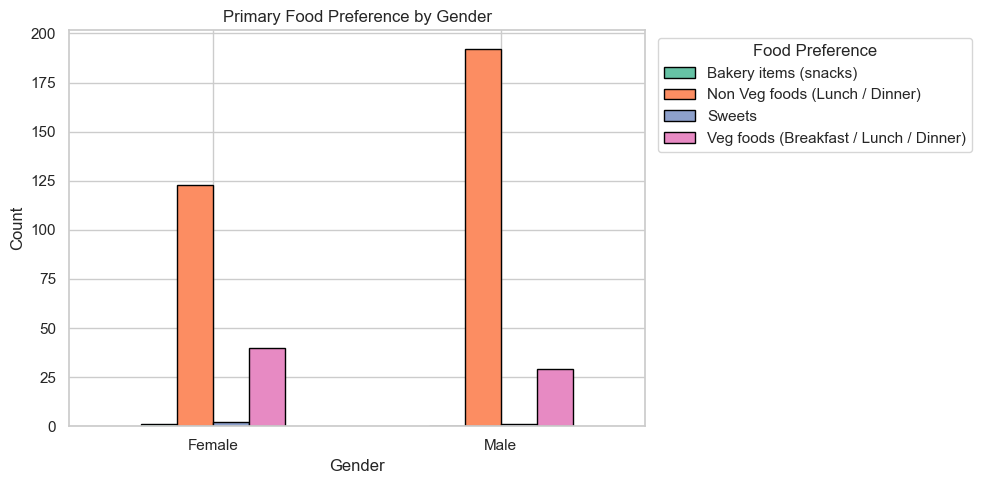

In [27]:
# Food preferences breakdown by Gender
pref_gender = df.groupby(['Gender', 'Perference(P1)']).size().unstack(fill_value=0)

pref_gender.plot(kind='bar', figsize=(10, 5), edgecolor='black',
                 color=sns.color_palette('Set2', pref_gender.shape[1]))
plt.title('Primary Food Preference by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Food Preference', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

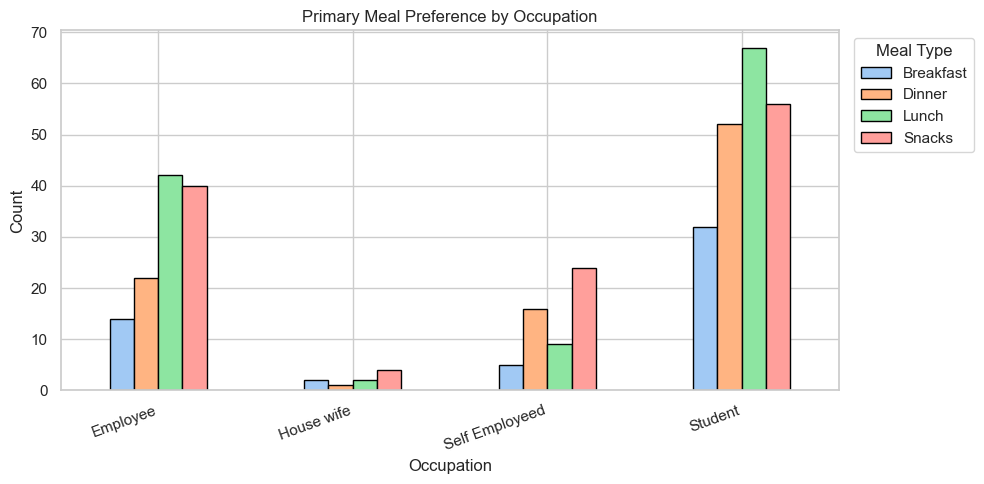

In [28]:
# Meal preferences breakdown by Occupation
meal_occ = df.groupby(['Occupation', 'Meal(P1)']).size().unstack(fill_value=0)

meal_occ.plot(kind='bar', figsize=(10, 5), edgecolor='black',
              color=sns.color_palette('pastel', meal_occ.shape[1]))
plt.title('Primary Meal Preference by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Meal Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 5. Dashboard Summary – Key Insights

In [29]:
# Compile key metrics
users_yes_pct = (df['Output'] == 'Yes').mean() * 100
top_locality = locality_orders.idxmax()
top_cuisine  = pref_combined.value_counts().idxmax()
top_meal     = meal_combined.value_counts().idxmax()
top_platform = medium_combined.value_counts().idxmax()
top_issue    = issue_series.idxmax()
top_factor   = rating_scores.idxmax()

print('=' * 65)
print('  DATA INSIGHTS DASHBOARD – KEY FINDINGS')
print('=' * 65)
print()
print(f'  Dataset          : {len(df)} respondents, 55 variables')
print(f'  City             : Bangalore, India')
print()
print('  ── Demographics ──────────────────────────────────────────')
print(f'  Majority gender  : {df["Gender"].value_counts().idxmax()}')
print(f'  Majority age     : 22–25 years (young urban professionals/students)')
print(f'  Majority occupation: {df["Occupation"].value_counts().idxmax()}')
print()
print('  ── Delivery Usage ────────────────────────────────────────')
print(f'  Use food delivery : {users_yes_pct:.1f}% of respondents')
print(f'  Top platform      : {top_platform}')
print(f'  Preferred order time: {df["Order Time"].mode()[0]}')
print()
print('  ── Delivery Time Analysis ────────────────────────────────')
print(f'  Min acceptable wait : {min_wait} minutes')
print(f'  Max acceptable wait : {max_wait} minutes (>60 min)')
print(f'  Most common wait    : {modal_wait}')
print(f'  Locality most orders: Pin code {most_orders_pin} ({most_orders_count} orders)')
print(f'  Locality least orders: Pin code {least_orders_pin} ({least_orders_count} order)')
print()
print('  ── Customer Satisfaction ─────────────────────────────────')
print(f'  Most important factor : {top_factor}')
print(f'  Top delivery issue    : {top_issue}')
print(f'  Rating influences order: {df["Influence of rating"].value_counts().idxmax()}')
print()
print('  ── Customer Preferences ──────────────────────────────────')
print(f'  Top cuisine/food type : {top_cuisine}')
print(f'  Most ordered meal     : {top_meal}')
print(f'  Top ordering platform : {top_platform}')
print()
print('  ── Business Recommendations ──────────────────────────────')
print('  1. Focus marketing on Pin code 560009 (highest order volume).')
print('  2. Guarantee delivery within 45 minutes – most customers will not')
print('     wait more; <30 min is a competitive differentiator.')
print('  3. Non-Veg and Veg options dominate – ensure wide menu coverage.')
print('  4. Dinner and Snacks are the most ordered meals – prioritise')
print('     peak-hour driver availability in the evening.')
print('  5. Food quality (taste, freshness, temperature) ranks highest in')
print('     importance – partner with high-quality restaurants.')
print('  6. Long delivery time is the top complaint – invest in route')
print('     optimisation and real-time driver tracking.')

  DATA INSIGHTS DASHBOARD – KEY FINDINGS

  Dataset          : 388 respondents, 55 variables
  City             : Bangalore, India

  ── Demographics ──────────────────────────────────────────
  Majority gender  : Male
  Majority age     : 22–25 years (young urban professionals/students)
  Majority occupation: Student

  ── Delivery Usage ────────────────────────────────────────
  Use food delivery : 77.6% of respondents
  Top platform      : Food delivery apps
  Preferred order time: Anytime (Mon-Sun)

  ── Delivery Time Analysis ────────────────────────────────
  Min acceptable wait : 15 minutes
  Max acceptable wait : 75 minutes (>60 min)
  Most common wait    : 45 minutes
  Locality most orders: Pin code 560009 (36 orders)
  Locality least orders: Pin code 560033 (1 order)

  ── Customer Satisfaction ─────────────────────────────────
  Most important factor : Good Taste
  Top delivery issue    : Delay of delivery person picking up food
  Rating influences order: Yes

  ── Customer 